In [4]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\Pavan
['.anaconda', '.conda', '.condarc', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'customer_behavior_analysis.ipynb', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{818b2893-44c6-11f0-957d-e6fd7f1e0ae5}.TM.blf', 'NTUSER.DAT{818b2893-44c6-11f0-957d-e6fd7f1e0ae5}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{818b2893-44c6-11f0-957d-e6fd7f1e0ae5}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PAVAN VEERA BARLA RESUME.pdf', 'practice.python', 'Practice_notes.py', 'Practice_session.py', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Swiggy_sales_analysis.ipynb', 'Templates', 'tips_analysis_project_ipynb', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled10.i

In [25]:
#import libraries
import pandas as pd
df = pd.read_csv('C:/Users/Pavan/OneDrive/Desktop/Documents/customer-behavior-analysis/data/customer_shopping_behavior.csv')

In [26]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [28]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [29]:
#find null values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [30]:
# fill null values
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [31]:

df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [32]:
#change column names to lowercasse and spaces replaces with underscore
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={ 'purchase_amount_(usd)':'purchase_amount'})

In [33]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [34]:
#Create a new a column
labels=['Young Adult','Adult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4, labels =labels)

In [35]:
df[['age','age_group']].head()

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged


In [36]:
# create a column purchase_frequency_days
frequency_mapping = {
    'Fortnightly':14,
    'Weekly':7,
    'Monthly':30,
    'Quarterly':90,
    'Bi-Weekly':14,
    'Annually':365,
    'Every 3 month':90
}
df['purchase_frequency_days']=df['frequency_of_purchases'].map(frequency_mapping)
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually
5,7.0,Weekly
6,90.0,Quarterly
7,7.0,Weekly
8,365.0,Annually
9,90.0,Quarterly


In [37]:
df=df.drop('promo_code_used',axis=1)     

In [38]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [40]:
# ===== EDA (Analysis) =====

# Category distribution
print(df['category'].value_counts())

# Gender distribution
print(df['gender'].value_counts())

# Avg purchase by category
print(df.groupby('category')['purchase_amount'].mean())

# Avg purchase by age group
print(df.groupby('age_group',observed=False)['purchase_amount'].mean())

category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64
gender
Male      2652
Female    1248
Name: count, dtype: int64
category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: purchase_amount, dtype: float64
age_group
Young Adult    60.450389
Adult          59.424628
Middle-aged    60.037525
Senior         59.070975
Name: purchase_amount, dtype: float64


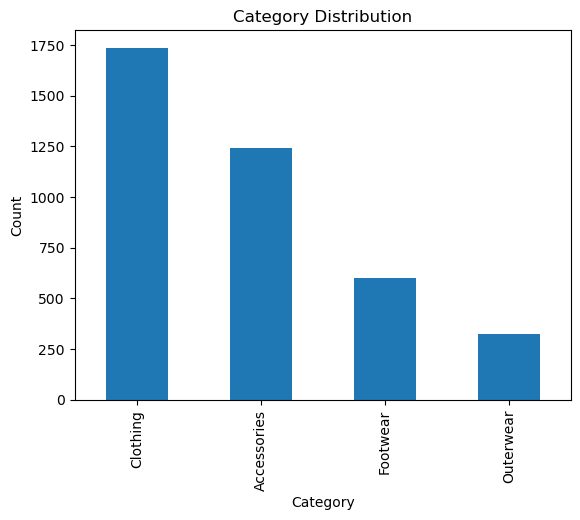

In [41]:
import matplotlib.pyplot as plt

# Category distribution
df['category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

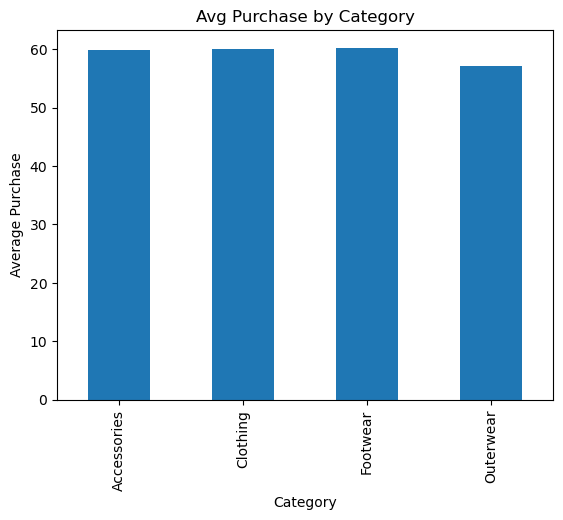

In [42]:
# Avg purchase by category
df.groupby('category')['purchase_amount'].mean().plot(kind='bar')
plt.title('Avg Purchase by Category')
plt.xlabel('Category')
plt.ylabel('Average Purchase')
plt.show()

In [17]:
!pip install mysql-connector-python sqlalchemy

In [43]:
#conncetions to mysql workbench
import pandas as pd
from sqlalchemy import create_engine
engine = create_engine('mysql+mysqlconnector://root@localhost:3306/shopping_project',
                      connect_args={'password':'Pavan@1234'}
                      )
print('Connection succesfully')

Connection succesfully


In [44]:
df.to_sql(
    name='customers',
    con=engine,
    if_exists='replace',
    index=False
)
print('Data uploaded to MySQL')

Data uploaded to MySQL
